# 중간 단계의 상태(State) 수동 업데이트

LangGraph는 **중간 단계의 상태를 수동으로 업데이트** 할 수 있는 방안을 제공하고 있습니다.

상태를 업데이트하면 **에이전트의 행동을 수정하여 경로를 제어** 할 수 있으며, 심지어 과거를 수정할 수도 있습니다. 

이 기능은 **에이전트의 실수를 수정** 하거나, **대체 경로를 탐색** 하거나, 특정 목표에 따라 **에이전트의 동작을 변경** 할 때 특히 유용합니다.

- 참고: 본 튜토리얼에서 사용하는 에이전트는 이전 튜토리얼과 동일한 그래프를 정의합니다.

> 참고 문서: [LangGraph Persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/)

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


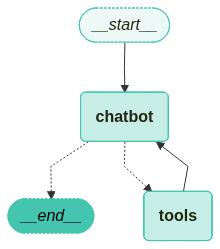

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_teddynote.tools.tavily import TavilySearch
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_teddynote.graphs import visualize_graph


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 도구 초기화
tool = TavilySearch(max_results=1)

# 도구 목록 정의
tools = [tool]

# LLM 초기화 (OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경)
llm = init_chat_model("claude-sonnet-4-5")

# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)


# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=tools)

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

########## 5. 그래프 컴파일 ##########
# 메모리 저장소 초기화
memory = MemorySaver()

# 그래프 빌더 컴파일
graph = graph_builder.compile(checkpointer=memory)

########## 6. 그래프 시각화 ##########
# 그래프 시각화
visualize_graph(graph)

In [4]:
from langchain_core.runnables import RunnableConfig

# 질문
question = "LangGraph 가 무엇인지 조사하여 알려주세요!"

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# config 설정
config = RunnableConfig(
    configurable={"thread_id": "1"},  # 스레드 ID 설정
)

우선 채널목록을 출력하여 **interrupt_before** 와 **interrupt_after** 를 적용할 수 있는 목록을 출력합니다.

아래 코드에서는 그래프의 채널 목록을 조회합니다.

In [5]:
# 그래프 채널 목록 출력
list(graph.channels)

['messages',
 '__start__',
 '__pregel_tasks',
 'branch:to:chatbot',
 'branch:to:tools']

In [6]:
# 그래프 스트림 호출
events = graph.stream(
    input=input, config=config, interrupt_before=["tools"], stream_mode="values"
)

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph 가 무엇인지 조사하여 알려주세요!
================================== Ai Message ==================================

[{'id': 'toolu_01QcdrxntgcSGEaaSVSrv4Ht', 'input': {'query': 'LangGraph 무엇인지 설명'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01QcdrxntgcSGEaaSVSrv4Ht)
 Call ID: toolu_01QcdrxntgcSGEaaSVSrv4Ht
  Args:
    query: LangGraph 무엇인지 설명


## 현재 상태 분석

현재 단계는 `ToolNode`에 의해 중단되었습니다. 가장 최근 메시지를 확인하면 `ToolNode`가 검색을 수행하기 전의 `query`를 포함하고 있음을 알 수 있습니다.

여기서는 `query`가 단순하게 `LangGraph`라는 단어만을 포함하고 있습니다. 기존의 질문은 `"LangGraph 가 무엇인지 조사하여 알려주세요!"`였지만, LLM이 추출한 검색 쿼리는 간단하게 압축되었습니다.

이런 경우 웹 검색 결과가 우리가 원하는 결과와 다를 수 있으므로, 상태를 수동으로 업데이트하여 검색 결과를 직접 지정할 수 있습니다.

아래 코드에서는 현재 스냅샷의 마지막 메시지를 확인합니다.

In [7]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 가장 최근 메시지 추출
last_message = snapshot.values["messages"][-1]

# 메시지 출력
last_message.pretty_print()

================================== Ai Message ==================================

[{'id': 'toolu_01QcdrxntgcSGEaaSVSrv4Ht', 'input': {'query': 'LangGraph 무엇인지 설명'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01QcdrxntgcSGEaaSVSrv4Ht)
 Call ID: toolu_01QcdrxntgcSGEaaSVSrv4Ht
  Args:
    query: LangGraph 무엇인지 설명


## 사람의 개입 (Human-in-the-loop)

- `TavilySearch` 도구에서 **검색 결과** 를 수정

우리는 종종 `ToolMessage` 의 결과가 마음에 들지 않는 경우가 있습니다.

특히, 웹 검색하여 얻은 답변은 얼마든지 잘못된 정보가 포함될 수 있고, 이는 곧 챗봇의 답변에도 영향을 미칠 수 있습니다.

만약, 사람이 중간에 개입하여 웹 검색 도구인 `Tavily Tool` 의 검색 결과인 `ToolMessage` 를 수정하여 LLM 에게 전달하고 싶다면 어떻게 해야 할까요?

![](./assets/langgraph-01.png)

### 수정된 검색 결과 생성

아래는 실제 웹 검색을 수행하는 대신, 우리가 직접 작성한 가상의 검색 결과입니다. 이렇게 수동으로 생성한 결과를 `ToolMessage`에 주입하여 LLM에게 전달할 수 있습니다.

이 방법을 통해 검색 결과의 품질을 보장하거나, 특정 정보를 LLM에게 제공할 수 있습니다.

아래 코드에서는 수정된 검색 결과 문자열을 생성합니다.

In [8]:
modified_search_result = """[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요."""

print(modified_search_result)

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.


다음으로는 수정한 검색 결과를 `ToolMessage` 에 주입합니다.

**중요**

- 여기서 메시지를 수정하려면 수정하고자 하는 Message 와 일치하는 `tool_call_id` 를 지정해야 합니다.

In [9]:
# 수정하고자 하는 `ToolMessage` 의 `tool_call_id` 추출
tool_call_id = last_message.tool_calls[0]["id"]
print(tool_call_id)

toolu_01QcdrxntgcSGEaaSVSrv4Ht


In [10]:
from langchain_core.messages import AIMessage, ToolMessage

new_messages = [
    # LLM API의 도구 호출과 일치하는 ToolMessage 필요
    ToolMessage(
        content=modified_search_result,
        tool_call_id=tool_call_id,
    ),
    # LLM의 응답에 직접적으로 내용 추가
    # AIMessage(content=modified_search_result),
]

new_messages[-1].pretty_print()

================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.


### StateGraph의 `update_state` 메서드

`update_state` 메서드는 주어진 값으로 그래프의 상태를 업데이트합니다. 이 메서드는 마치 `as_node`에서 값이 온 것처럼 동작합니다.

**매개변수**

- `config` (RunnableConfig): 실행 구성
- `values` (Optional[Union[dict[str, Any], Any]]): 업데이트할 값들
- `as_node` (Optional[str]): 값의 출처로 간주할 노드 이름. 기본값은 None

**반환값**

- RunnableConfig

**주요 기능**

1. 체크포인터를 통해 이전 상태를 로드하고 새로운 상태를 저장합니다.
2. 서브그래프에 대한 상태 업데이트를 처리합니다.
3. `as_node`가 지정되지 않은 경우, 마지막으로 상태를 업데이트한 노드를 찾습니다.
4. 지정된 노드의 writer들을 실행하여 상태를 업데이트합니다.
5. 업데이트된 상태를 체크포인트에 저장합니다.

**주요 로직**

1. 체크포인터를 확인하고, 없으면 ValueError를 발생시킵니다.
2. 서브그래프에 대한 업데이트인 경우, 해당 서브그래프의 `update_state` 메서드를 호출합니다.
3. 이전 체크포인트를 로드하고, 필요한 경우 `as_node`를 결정합니다.
4. 지정된 노드의 writer들을 사용하여 상태를 업데이트합니다.
5. 업데이트된 상태를 새로운 체크포인트로 저장합니다.

**참고**

- 이 메서드는 그래프의 상태를 수동으로 업데이트할 때 사용됩니다.
- 체크포인터를 사용하여 상태의 버전 관리와 지속성을 보장합니다.
- `as_node`를 지정하지 않으면 자동으로 결정되지만, 모호한 경우 오류가 발생할 수 있습니다.
- 상태 업데이트 중 SharedValues에 쓰기 작업은 허용되지 않습니다.

In [11]:
graph.update_state(
    # 업데이트할 상태 지정
    config,
    # 제공할 업데이트된 값. `State`의 메시지는 "추가 전용"으로 기존 상태에 추가됨
    {"messages": new_messages},
    as_node="tools",
)

print("(최근 1개의 메시지 출력)\n")
print(graph.get_state(config).values["messages"][-1])

(최근 1개의 메시지 출력)

content='[수정된 웹 검색 결과] \nLangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.\nLangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.\n\n자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과\n테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.' id='989297fe-064e-450a-ba07-f34f3b3e3c4a' tool_call_id='toolu_01QcdrxntgcSGEaaSVSrv4Ht'


이제 그래프가 완성되었습니다. 

최종 응답 메시지를 제공했기 때문입니다! 

상태 업데이트는 그래프 단계를 시뮬레이션하므로, 해당하는 `traces`도 생성합니다.

`messages`를 사전 정의된 `add_messages` 함수로 `Annotated` 처리했습니다. (이는 그래프에 기존 목록을 직접 덮어쓰지 않고 항상 값을 추가합니다.)

동일한 논리가 여기에도 적용되어, `update_state`에 전달된 메시지가 동일한 방식으로 메시지가 추가하게 됩니다.

`update_state` 함수는 마치 그래프의 노드 중 하나인 것처럼 작동합니다! 기본적으로 업데이트 작업은 마지막으로 실행된 노드를 사용하지만, 아래에서 수동으로 지정할 수 있습니다. 업데이트를 추가하고 그래프에 "chatbot"에서 온 것처럼 처리하도록 지시해 봅시다.


In [12]:
snapshot = graph.get_state(config)
snapshot.next

('chatbot',)

In [13]:
# `None`는 현재 상태에 아무것도 추가하지 않음
events = graph.stream(None, config, stream_mode="values")

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.
================================== Ai Message ==================================

[{'id': 'toolu_011bsHiSVKrbRQVUgFbcCWAk', 'input': {'query': 'LangGraph features use cases examples'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_011bsHiSVKrbRQVUgFbcCWAk)
 Call ID: toolu_011bsHiSVKrbRQVUgFbcCWAk
  Args:
    query: LangGraph features use cases examples
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.scalablepath.com/machine-learning/langgraph", "title": "Building AI Workflows with

아래 코드는 최종 답변의 상태도 수정하고자 할 경우 사용할 수 있는 예시입니다.

In [14]:
# 이 함수가 작동할 노드 지정. 이 노드가 방금 실행된 것처럼 자동으로 처리 계속
# graph.update_state(
#     config,
#     {
#         "messages": [
#             AIMessage(content="마지막으로 최종 메시지를 추가하여 마무리 합니다.")
#         ]
#     },
#     as_node="chatbot",
# )

그럼, 그래프를 시각화하고 전체 출력을 확인해 보겠습니다.

아래 코드에서는 `visualize_graph`를 사용하여 그래프를 시각화합니다.

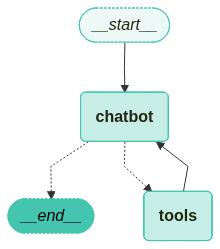

In [14]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

현재 상태를 이전과 같이 점검하여 체크포인트가 수동 업데이트를 반영하는지 확인합니다.

아래 코드에서는 스냅샷의 전체 메시지를 순회하며 출력합니다.

In [15]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 최근 세 개의 메시지 출력
for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

LangGraph 가 무엇인지 조사하여 알려주세요!
================================== Ai Message ==================================

[{'id': 'toolu_01QcdrxntgcSGEaaSVSrv4Ht', 'input': {'query': 'LangGraph 무엇인지 설명'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01QcdrxntgcSGEaaSVSrv4Ht)
 Call ID: toolu_01QcdrxntgcSGEaaSVSrv4Ht
  Args:
    query: LangGraph 무엇인지 설명
================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.
================================== Ai Message ==================================

[{'id': 'toolu_011bsHiSVKrbRQVUgFbcCWAk', 'input': {'quer

진행할 다음 노드가 있는지 확인합니다. `()` 가 비어 있는 것으로 확인할 수 있습니다. 즉, 모든 과정이 정상적으로 진행되었음을 알 수 있습니다.

아래 코드에서는 스냅샷의 `next` 속성을 출력하여 다음 실행 노드를 확인합니다.

In [16]:
# 다음 상태 출력
print(snapshot.next)

()


## Interrupt 후 메시지 상태 업데이트 - 이어서 진행

- `TavilySearch` 도구에서 **검색 쿼리** 를 수정

이번에는 다음 노드로 진행하기 전 interrupt 를 발생시켜 중단하고, 상태(State) 를 갱신한 뒤 이어서 진행하는 방법을 살펴보겠습니다.

먼저, 새로운 `thread_id` 를 생성합니다.

여기서는 랜덤한 해시값을 생성하는 `generate_random_hash` 함수를 사용합니다.

In [17]:
from langchain_teddynote.graphs import generate_random_hash

thread_id = generate_random_hash()
print(f"thread_id: {thread_id}")

question = "LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!"

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# 새로운 config 생성
config = {"configurable": {"thread_id": thread_id}}

events = graph.stream(
    input=input,
    config=config,
    interrupt_before=["tools"],
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

thread_id: d3d72e
================================ Human Message =================================

LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!
================================== Ai Message ==================================

[{'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'input': {'query': 'LangGraph tutorial learning resources documentation'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01ETAukduc6BZgtA9BZ9TPUh)
 Call ID: toolu_01ETAukduc6BZgtA9BZ9TPUh
  Args:
    query: LangGraph tutorial learning resources documentation


## 검색 쿼리 수정하기

이번에는 도구 호출의 검색 쿼리 자체를 수정하는 방법을 살펴봅니다. LLM이 생성한 검색 쿼리가 부적절하다고 판단되면, 직접 수정하여 더 나은 검색 결과를 얻을 수 있습니다.

에이전트의 도구 호출을 업데이트하려면 기존 메시지의 `tool_calls` 정보를 수정하면 됩니다.

아래 코드에서는 현재 config를 복사하고 스냅샷에서 메시지를 가져옵니다.

### 메시지 ID 가져오기

상태를 업데이트하려면 수정하고자 하는 메시지의 ID가 필요합니다. 동일한 ID를 사용하면 `add_messages` 리듀서가 기존 메시지를 새 메시지로 대체합니다.

아래 코드에서는 현재 config를 복사하고 스냅샷에서 메시지 ID를 가져옵니다.

In [18]:
# config 를 복사
config_copy = config.copy()

In [19]:
from langchain_core.messages import AIMessage

# 스냅샷 상태 가져오기
snapshot = graph.get_state(config)

# messages 의 마지막 메시지 가져오기
existing_message = snapshot.values["messages"][-1]

# 메시지 ID 출력
print("Message ID", existing_message.id)

Message ID lc_run--019ca0f3-f43c-7680-8081-d53c2ca46b90-0


마지막 메시지는 `tavily_web_search` 도구 호출과 관련된 메시지 입니다.

주요 속성은 다음과 같습니다.

- `name`: 도구의 이름
- `args`: 검색 쿼리
- `id`: 도구 호출 ID
- `type`: 도구 호출 유형(tool_call)

In [20]:
# 첫 번째 도구 호출 출력
print(existing_message.tool_calls[0])

{'name': 'tavily_web_search', 'args': {'query': 'LangGraph tutorial learning resources documentation'}, 'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'type': 'tool_call'}


위의 속성 값 중 `args` 의 `query` 를 업데이트 해 보겠습니다.

기존의 `existing_message` 를 복사하여 새로운 도구인 `new_tool_call` 을 생성합니다.

`copy()` 메서드를 사용하여 복사하였기 때문에 모든 속성 값이 복사됩니다.

그런 다음, `query` 매개변수에 원하는 **검색 쿼리** 를 입력합니다.

**중요**

- `id` 는 기존 메시지의 `id` 를 그대로 사용합니다. (`id` 가 달라지면 message 리듀서가 동작하여 메시지를 갱신하지 않고, 추가하게 됩니다.)

아래 코드에서는 기존 `tool_calls`를 복사한 뒤 검색 쿼리를 새로운 값으로 교체합니다.

In [21]:
# tool_calls 를 복사하여 새로운 도구 호출 생성
new_tool_call = existing_message.tool_calls[0].copy()

# 쿼리 매개변수 업데이트(갱신)
new_tool_call["args"] = {"query": "LangGraph site:teddylee777.github.io"}
new_tool_call

{'name': 'tavily_web_search',
 'args': {'query': 'LangGraph site:teddylee777.github.io'},
 'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh',
 'type': 'tool_call'}

In [22]:
# AIMessage 생성
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    # 중요! ID는 메시지를 상태에 추가하는 대신 교체하는 방법
    id=existing_message.id,
)

print(new_message.id)

# 수정한 메시지 출력
new_message.pretty_print()

lc_run--019ca0f3-f43c-7680-8081-d53c2ca46b90-0
================================== Ai Message ==================================

[{'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'input': {'query': 'LangGraph tutorial learning resources documentation'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01ETAukduc6BZgtA9BZ9TPUh)
 Call ID: toolu_01ETAukduc6BZgtA9BZ9TPUh
  Args:
    query: LangGraph site:teddylee777.github.io


검색 쿼리가 갱신된 것을 확인할 수 있습니다.

아래 코드에서는 갱신된 도구 호출 정보를 출력하고, `update_state`로 상태를 업데이트합니다.

In [23]:
# 업데이트된 도구 호출 출력
print(new_message.tool_calls[0])

# 메시지 ID 출력
print("\nMessage ID", new_message.id)

# 상태 업데이트
graph.update_state(config, {"messages": [new_message]})

{'name': 'tavily_web_search', 'args': {'query': 'LangGraph site:teddylee777.github.io'}, 'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'type': 'tool_call'}

Message ID lc_run--019ca0f3-f43c-7680-8081-d53c2ca46b90-0


{'configurable': {'thread_id': 'd3d72e',
  'checkpoint_ns': '',
  'checkpoint_id': '1f114215-a163-682a-8002-07fcd142bb48'}}

업데이트된 마지막 message 의 `tool_calls` 를 확인합니다.

- `args` 의 `query` 가 수정된 것을 확인할 수 있습니다.

아래 코드에서는 상태에서 마지막 메시지의 `tool_calls`를 조회하여 쿼리가 변경되었는지 확인합니다.

In [24]:
# 마지막 메시지의 도구 호출 가져오기
graph.get_state(config).values["messages"][-1].tool_calls

[{'name': 'tavily_web_search',
  'args': {'query': 'LangGraph site:teddylee777.github.io'},
  'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh',
  'type': 'tool_call'}]

기존 검색어인 **"LangGraph"** 대신 변경된 검색 쿼리인 **"LangGraph site:teddylee777.github.io"** 로 검색되는 것을 확인할 수 있습니다.

아래 코드에서는 기존 설정과 `None` 입력을 사용하여 그래프를 이어서 스트리밍합니다.

In [25]:
# 그래프 스트림에서 이벤트 수신
events = graph.stream(None, config, stream_mode="values")

# 각 이벤트에 대한 처리
for event in events:
    # 메시지가 있는 경우 마지막 메시지 출력
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'input': {'query': 'LangGraph tutorial learning resources documentation'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01ETAukduc6BZgtA9BZ9TPUh)
 Call ID: toolu_01ETAukduc6BZgtA9BZ9TPUh
  Args:
    query: LangGraph site:teddylee777.github.io
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://teddylee777.github.io/langgraph/langgraph-multi-agent-collaboration/", "title": "LangGraph - Multi-Agent Collaboration(다중 협업 에이전트) 로 ...", "content": "{'Chart Generator': {'messages': [HumanMessage(content='', additional_kwargs={'function_call': {'arguments': '{\"code\":\"import matplotlib.pyplot as plt\\\\n\\\\n# Data\\\\nyears = [2018, 2020, 2021, 2022, 2024, 2025]\\\\nfertility_rates = [0.98, 0.84, 0.81, 0.78, 0.7, 0.65]\\\\n\\\

In [26]:
# 이벤트 스트림 생성
events = graph.stream(
    {
        "messages": (
            "user",
            "내가 지금까지 배운 내용에 대해서 매우 친절하고 정성스럽게 한국어로 답변해줘! 출처를 반드시 포함해줘!",
        )
    },
    config,
    stream_mode="values",
)

# 메시지 이벤트 처리
for event in events:
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================ Human Message =================================

내가 지금까지 배운 내용에 대해서 매우 친절하고 정성스럽게 한국어로 답변해줘! 출처를 반드시 포함해줘!
================================== Ai Message ==================================

[{'id': 'toolu_0128CYLoLu2DeBQDLiWKCWQG', 'input': {'query': 'LangGraph 기본 개념 설명 튜토리얼 한국어'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}, {'id': 'toolu_0118qMHv5scYZ4YNeEdYpNiA', 'input': {'query': 'LangGraph StateGraph Node Edge 설명'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_0128CYLoLu2DeBQDLiWKCWQG)
 Call ID: toolu_0128CYLoLu2DeBQDLiWKCWQG
  Args:
    query: LangGraph 기본 개념 설명 튜토리얼 한국어
  tavily_web_search (toolu_0118qMHv5scYZ4YNeEdYpNiA)
 Call ID: toolu_0118qMHv5scYZ4YNeEdYpNiA
  Args:
    query: LangGraph StateGraph Node Edge 설명
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://blo

최종 상태에서 `messages` 의 마지막 메시지를 확인합니다. (이는 곧 최종 응답 메시지입니다.)

아래 코드에서는 `get_state`를 사용하여 최종 상태의 마지막 메시지를 출력합니다.

In [27]:
graph.get_state(config).values["messages"][-1].pretty_print()

================================== Ai Message ==================================

좋습니다! LangGraph에 대해 배우고 싶으시군요. 제가 검색한 자료를 바탕으로 매우 친절하고 정성스럽게 설명해드리겠습니다! 😊

# LangGraph 완벽 학습 가이드 🚀

## 📌 LangGraph란 무엇인가요?

**LangGraph**는 LangChain에서 개발한 프레임워크로, **복잡한 AI 에이전트 워크플로우를 그래프 형태로 구성**할 수 있게 해주는 도구입니다. 기존의 단방향 체인 방식의 한계를 극복하고, **순환(Cycle)이 가능한 동적인 워크플로우**를 만들 수 있습니다.

**출처**: [테디노트 블로그 - LangGraph Multi-Agent Collaboration](https://teddylee777.github.io/langgraph/langgraph-multi-agent-collaboration/)

---

## 🎯 왜 LangGraph가 필요한가요?

### 기존 방식(Naive RAG)의 문제점:
- **단방향 파이프라인**: 한 번에 모든 단계를 완벽하게 수행해야 함
- **피드백 불가능**: 중간에 문제가 발생해도 되돌릴 수 없음
- **복잡도 증가**: 기능을 추가할수록 체인이 덕지덕지 붙음
- **유연성 부족**: 조건에 따른 동적 분기가 어려움

**출처**: [테디노트 블로그](https://teddylee777.github.io/langgraph/langgraph-multi-agent-collaboration/)

---

## 🔑 LangGraph 핵심 개념

### 1️⃣ **State (상태)**
- 노드와 노드 간의 정보를 전달하는 **택배 상자**
- `TypedDict`를 상속받아 정의
- 각 노드는 독립적이므로 State를 통해서만 통신

```python
from typing import TypedDict, Annotated
from operator

## 지난 스냅샷의 결과 수정 및 Replay

이번에는 지난 스냅샷의 결과를 수정하여 Replay 하는 방법을 살펴보겠습니다.

지난 스냅샷을 확인 후 특정 노드로 되돌아가, **상태(State) 를 수정한 뒤 해당 노드부터 다시 진행**합니다.

이를 Replay 라고 합니다.

아래 코드에서는 `get_state_history`를 사용하여 상태 이력을 순회하고, 메시지가 2개인 시점의 스냅샷을 선택합니다.

In [28]:
to_replay_state = None

# 상태 기록 가져오기
for state in graph.get_state_history(config):

    messages = state.values["messages"]

    if len(messages) > 0:
        print(state.values["messages"][-1].id)
        # 메시지 수 및 다음 상태 출력
        print("메시지 수: ", len(state.values["messages"]), "다음 노드: ", state.next)
        print("-" * 80)
        # 특정 상태 선택 기준: 채팅 메시지 수
        if len(state.values["messages"]) == 2:
            # 특정 메시지 ID 선택
            to_replay_state = state

lc_run--019ca0f4-f942-7310-8b5c-a5625148768d-0
메시지 수:  9 다음 노드:  ()
--------------------------------------------------------------------------------
0bbd16a3-d56d-424f-ab98-6fbe019c494a
메시지 수:  8 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
lc_run--019ca0f4-d095-7910-bdef-4160e47f733a-0
메시지 수:  6 다음 노드:  ('tools',)
--------------------------------------------------------------------------------
ffc11e8e-a7e4-40dc-8315-70edd66b8ef8
메시지 수:  5 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
lc_run--019ca0f4-71ab-7542-b022-db93d76f17ab-0
메시지 수:  4 다음 노드:  ('__start__',)
--------------------------------------------------------------------------------
lc_run--019ca0f4-71ab-7542-b022-db93d76f17ab-0
메시지 수:  4 다음 노드:  ()
--------------------------------------------------------------------------------
552f10a9-24b3-4946-ba11-a9f3b007d548
메시지 수:  3 다음 노드:  ('chatbot',)
------------------

선택한 메시지의 내용을 확인합니다.

아래 코드에서는 `display_message_tree`를 사용하여 선택한 메시지의 상세 구조를 트리 형태로 출력합니다.

In [29]:
from langchain_teddynote.messages import display_message_tree

# 선택한 메시지 가져오기
existing_message = to_replay_state.values["messages"][-1]

# 메시지 트리 출력
display_message_tree(existing_message)

    content:
        index [0]
            id: "toolu_01ETAukduc6BZgtA9BZ9TPUh"
            input: {"query": "LangGraph tutorial learning resources documentation"}
            name: "tavily_web_search"
            type: "tool_use"
            caller: {"type": "direct"}
    additional_kwargs: {}
    response_metadata:
        id: "msg_017xvR5TpiDmoGH6ens5imnC"
        model: "claude-sonnet-4-5-20250929"
        stop_reason: "tool_use"
        stop_sequence: None
        usage:
            cache_creation: {"ephemeral_1h_input_tokens": 0, "ephemeral_5m_input_tokens": 0}
            cache_creation_input_tokens: 0
            cache_read_input_tokens: 0
            input_tokens: 665
            output_tokens: 62
            server_tool_use: None
            service_tier: "standard"
            inference_geo: "not_available"
        model_name: "claude-sonnet-4-5-20250929"
        model_provider: "anthropic"
    type: "ai"
    name: None
    id: "lc_run--019ca0f3-f43c-7680-8081-d53c2ca46b90-0

검색 쿼리를 업데이트 후 반영이 됐는지 확인합니다.

아래 코드에서는 기존 `tool_calls`를 복사한 뒤 새로운 검색 쿼리로 교체합니다.

In [30]:
tool_call = existing_message.tool_calls[0].copy()
tool_call["args"] = {"query": "LangGraph human-in-the-loop workflow site:reddit.com"}
tool_call

{'name': 'tavily_web_search',
 'args': {'query': 'LangGraph human-in-the-loop workflow site:reddit.com'},
 'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh',
 'type': 'tool_call'}

업데이트된 AIMessage 를 생성합니다.

In [31]:
# AIMessage 생성
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[tool_call],
    # 중요! ID는 메시지를 상태에 추가하는 대신 교체하는 방법
    id=existing_message.id,
)

# 수정한 메시지 출력
new_message.tool_calls[0]["args"]

{'query': 'LangGraph human-in-the-loop workflow site:reddit.com'}

아래 코드에서는 업데이트되기 전의 원본 메시지를 확인합니다.

In [32]:
# 업데이트 전 메시지 확인
graph.get_state(to_replay_state.config).values["messages"][-1].tool_calls

[{'name': 'tavily_web_search',
  'args': {'query': 'LangGraph tutorial learning resources documentation'},
  'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh',
  'type': 'tool_call'}]

`graph` 에 `update_state` 메서드를 사용하여 상태를 업데이트 합니다.

아래 코드에서는 `update_state` 메서드를 호출하여 수정된 메시지로 상태를 업데이트하고, 결과를 `updated_state`에 저장합니다.

In [33]:
# 상태 업데이트
updated_state = graph.update_state(
    to_replay_state.config,
    {"messages": [new_message]},
)
updated_state

{'configurable': {'thread_id': 'd3d72e',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11421a-39d2-6a08-8002-325ec5d24190'}}

이제 업데이트된 상태를 스트리밍 합니다. 여기서 입력은 `None` 으로 주어 Replay 합니다.

아래 코드에서는 `updated_state`를 config로 전달하여 수정된 상태에서 그래프를 이어서 실행합니다.

In [34]:
# config 에는 updated_state 를 전달합니다. 이는 임의로 갱신한 상태를 전달하는 것입니다.
for event in graph.stream(None, updated_state, stream_mode="values"):
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'input': {'query': 'LangGraph tutorial learning resources documentation'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01ETAukduc6BZgtA9BZ9TPUh)
 Call ID: toolu_01ETAukduc6BZgtA9BZ9TPUh
  Args:
    query: LangGraph human-in-the-loop workflow site:reddit.com
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.reddit.com/r/LangChain/comments/1bjnmu4/human_intervention_in_agent_workflows/", "title": "Human intervention in agent workflows : r/LangChain - Reddit", "content": "I know there is a Human-in-the-loop component in LangGraph that will prompt the user for input. But what if I'm not creating a user-initiated", "score": 0.767429, "raw_content": "![r/LangChain icon](https://styles.redditmedia.com/t5_7tpn6r/styles/co

최종 결과를 출력합니다.

이때 사용하는 `config` 는 최종 상태를 가져오는 것이 아니라, 최종 상태를 가져오기 위한 초기 `config` 입니다.

아래 코드에서는 `get_state`로 최종 상태를 가져온 뒤 모든 메시지를 출력합니다.

In [35]:
# 최종 결과 출력
for msg in graph.get_state(config).values["messages"]:
    msg.pretty_print()

================================ Human Message =================================

LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!
================================== Ai Message ==================================

[{'id': 'toolu_01ETAukduc6BZgtA9BZ9TPUh', 'input': {'query': 'LangGraph tutorial learning resources documentation'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_web_search (toolu_01ETAukduc6BZgtA9BZ9TPUh)
 Call ID: toolu_01ETAukduc6BZgtA9BZ9TPUh
  Args:
    query: LangGraph human-in-the-loop workflow site:reddit.com
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.reddit.com/r/LangChain/comments/1bjnmu4/human_intervention_in_agent_workflows/", "title": "Human intervention in agent workflows : r/LangChain - Reddit", "content": "I know there is a Human-in-the-loop component in LangGraph that will prompt the user for input. But what if I'm not creatin